In [1]:
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor, BlipProcessor, BlipForConditionalGeneration, pipeline
from qwen_vl_utils import process_vision_info
import gradio as gr
import zipfile
import os
import numpy as np
import random
import shutil
import pandas as pd
import cv2
from qwen import read_blue_channel
import yaml
from qwen import read_blue_channel, extract_zip_path, generate_random_sample
from langchain.prompts import PromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
import json

c:\Users\archi\anaconda3\envs\asid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\transfo

In [2]:
HOME = os.path.expanduser('~') + "\\ecdna-analysis"
config_path = os.path.join(HOME, "config.yaml")

In [3]:
config = open(config_path)
var = yaml.load(config, Loader=yaml.FullLoader)['qwen']
var

{'zipfile_path': 'data\\ecSeg_dataset.zip',
 'test_folder_name': 'test_im',
 'test_extract_folder': 'test_im_images',
 'train_folder_name': 'train_im',
 'train_extract_folder': 'train_im_images',
 'sampled': 'sampled',
 'sample_size': 200}

In [4]:
zip_file_path = os.path.join(HOME, var['zipfile_path'])
test_folder_name = var['test_folder_name']
test_extract_folder = os.path.join(HOME, var['test_extract_folder'])
train_folder_name = var['train_folder_name']
train_extract_folder = os.path.join(HOME, var['train_extract_folder'])

In [5]:
zip_file_path

'C:\\Users\\archi\\ecdna-analysis\\data\\ecSeg_dataset.zip'

In [6]:
extract_zip_path(zip_file_path, train_folder_name, train_extract_folder)
extract_zip_path(zip_file_path, test_folder_name, test_extract_folder)

In [7]:
sample_size = var['sample_size']
input_folder = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
output_folder = os.path.join(HOME, var['sampled'] )

In [8]:
generate_random_sample(input_folder, output_folder, sample_size)

1189


,0
0,1826.tif
1,1854.tif
2,510.tif
3,315.tif
4,725.tif
...,...
195,193.tif
196,194.tif
197,652.tif
198,115.tif


In [9]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.54s/it]


In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = model.to(device)
model.get_parameter

cuda


<bound method Module.get_parameter of Qwen2VLForConditionalGeneration(
  (visual): Qwen2VisionTransformerPretrainedModel(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
    )
    (rotary_pos_emb): VisionRotaryEmbedding()
    (blocks): ModuleList(
      (0-31): 32 x Qwen2VLVisionBlock(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): VisionAttention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (mlp): VisionMlp(
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
          (act): QuickGELUActivation()
          (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
    )
    (merger): PatchMerger(
      (ln_q): LayerNorm((1280,), eps=1e-06, element

In [11]:
test_images = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
train_images = os.path.join(train_extract_folder , f'ecSeg_dataset\\{train_folder_name}')

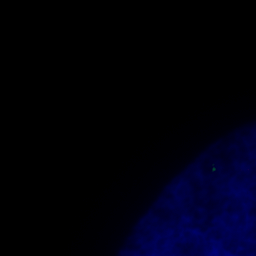

In [12]:
# Define the system message
system_message = "You are a pathologist studying metaphase cell images. The images are stained with DAPI 4' 6'' and these images contain different structures."

# Define a standard prompt template to ask for counts in the desired format
count_prompt_template = """
{system_message}

The following is an image description. You need to count and format the numbers of:
- ecDNA (small round structures)
- chromosomes (long structures)
- nuclei (big round structures)

Count all the nuclei in the image, then the chromosomes, and then ecDNA. Format the response as {{ "nuclei": number, "chromosomes": number, "ecDNA": number }}
"""
img_num = 2504
img_path = os.path.join(train_images, f'{img_num}.tif')
Image.open(img_path)

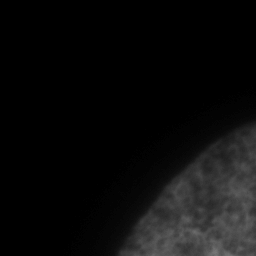

In [13]:
read_blue_channel(img_path)

In [35]:
def get_predictions(system_message, root_folder, image):
    """
        This function generates the prediction of the number of nuclei, chromosomes, and ecDNA
        in a cell image.

        Inputs:
            system_message: description specifying the role of the model when making predictions
            root_folder: folder storing all the images (either train_images or test_images)
            image: number of the image followed by .tif extension
        Returns:
            JSON string containing the counts of nuclei, chromosomes, and ecDNA
    """
    
    prompt = PromptTemplate(
        input_variables=["system_message"],
        template=count_prompt_template
    )

    img_path = os.path.join(root_folder, image)
    formatted_prompt = prompt.format(system_message=system_message)
    img = read_blue_channel(img_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": formatted_prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(device)

    generated_ids = model.generate(**inputs, max_new_tokens=120)

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    with open('C:/Users/archi/ecdna-analysis/qwen/output.txt', 'w') as f:
        f.write(output_text)
    
    f.close()

    return output_text

   

In [36]:
train = pd.read_csv('C:/Users/archi/ecdna-analysis/train_images_counts.csv')
print(train.shape)
train.head()

(4760, 4)


,image,num_nuclei,num_chromosomes,num_ecDNA
0,2343.tif,1,0,0
1,2344.tif,2,0,0
2,2345.tif,0,5,0
3,2346.tif,0,18,0
4,2347.tif,1,6,1


In [37]:
test = pd.read_csv('C:/Users/archi/ecdna-analysis/test_images_counts.csv')
print(test.shape)
test.head()

(1189, 4)


,image,num_nuclei,num_chromosomes,num_ecDNA
0,0.tif,2,1,1
1,1.tif,4,1,3
2,10.tif,1,6,2
3,1000.tif,2,4,2
4,1001.tif,1,0,0


In [43]:
get_predictions(system_message, train_images, train['image'].iloc[670])

'{"nuclei": 1, "chromosomes": 2, "ecDNA": 0}'

In [18]:
# # Get all train_predictions
# train['output'] = train['image'].apply(lambda image: json.loads(get_predictions(system_message, train_images, image)))
# train['pred_nuclei'] = train['output'].apply(lambda out: out['nuclei'])
# train['pred_chromosomes'] = train['output'].apply(lambda out: out['chromosomes'])
# train['pred_ecDNA'] = train['output'].apply(lambda out: out['ecDNA'])

In [44]:
# train

In [ ]:
test['output'] = test['image'].apply(lambda image: json.loads(get_predictions(system_message, test_images, image)))
test['pred_nuclei'] = test['output'].apply(lambda out: out['nuclei'])
test['pred_chromosomes'] = test['output'].apply(lambda out: out['chromosomes'])
test['pred_ecDNA'] = test['output'].apply(lambda out: out['ecDNA'])

In [ ]:
# test